In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [55]:
training_data = pd.read_csv('/content/Train.csv')

In [56]:
training_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [57]:
training_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


Replacing the missing values

In [58]:
meen = training_data['Item_Weight'].mean()

In [59]:
training_data['Item_Weight'].fillna(meen, inplace=True)

In [60]:
# Fix: Use groupby and transform to fill missing 'Outlet_Size' based on 'Outlet_Type'
training_data['Outlet_Size'] = training_data.groupby('Outlet_Type')['Outlet_Size'].transform(lambda x: x.fillna(x.mode()[0]))

In [61]:
training_data.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [62]:
training_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [63]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [64]:
sns.set()

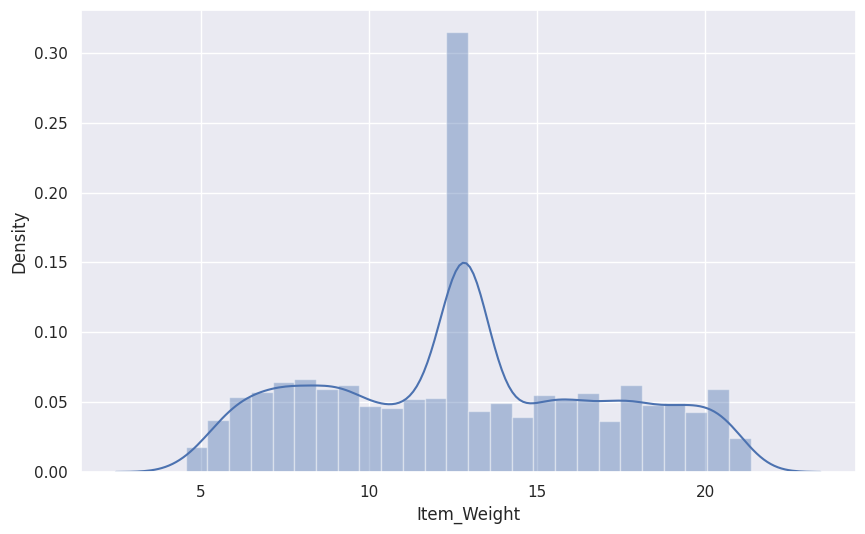

In [65]:
plt.figure(figsize=(10,6))
sns.distplot(training_data['Item_Weight'])
plt.show()

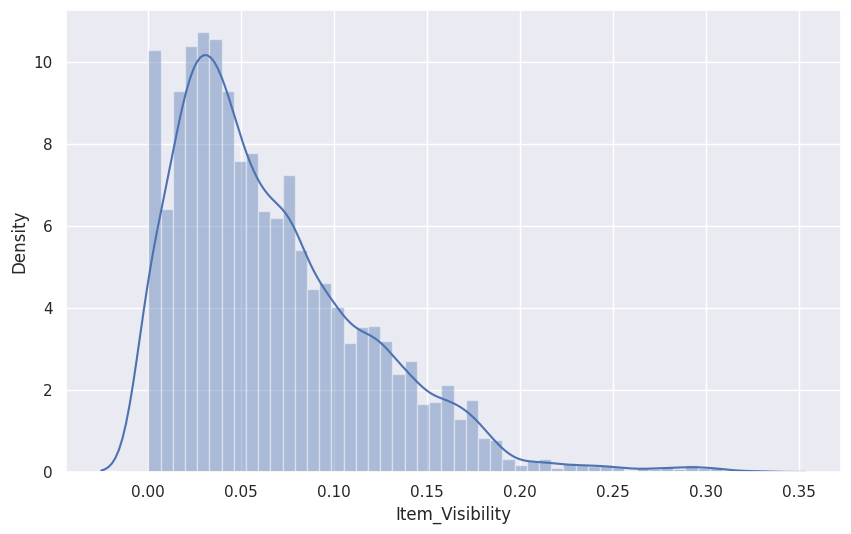

In [66]:
plt.figure(figsize=(10,6))
sns.distplot(training_data['Item_Visibility'])
plt.show()

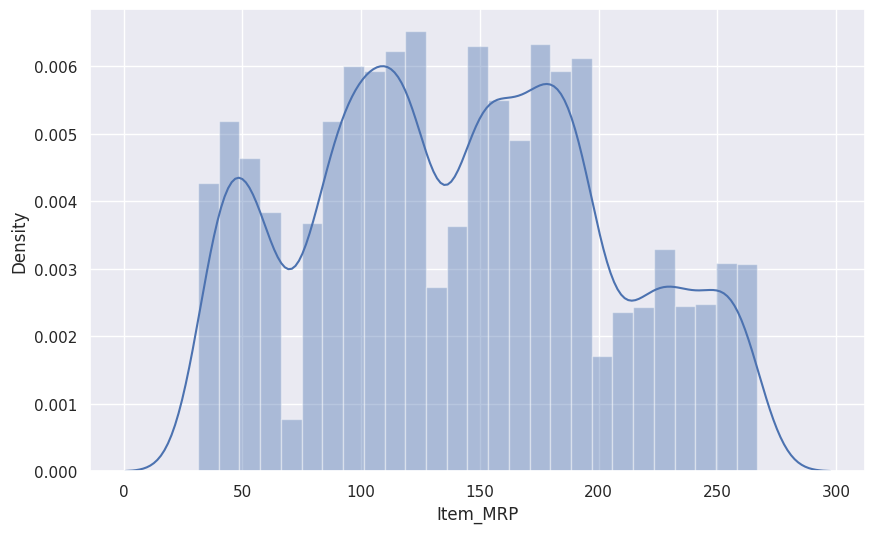

In [67]:
plt.figure(figsize=(10,6))
sns.distplot(training_data['Item_MRP'])
plt.show()

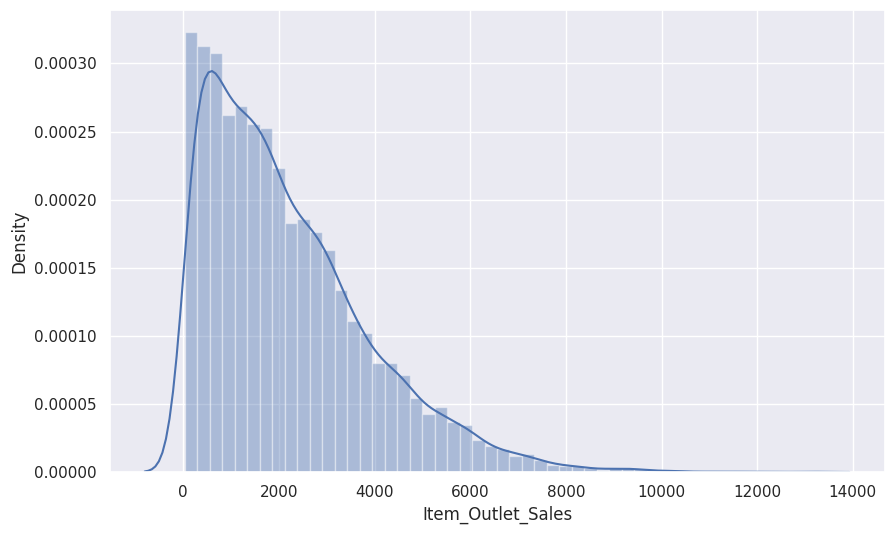

In [68]:
plt.figure(figsize=(10,6))
sns.distplot(training_data['Item_Outlet_Sales'])
plt.show()

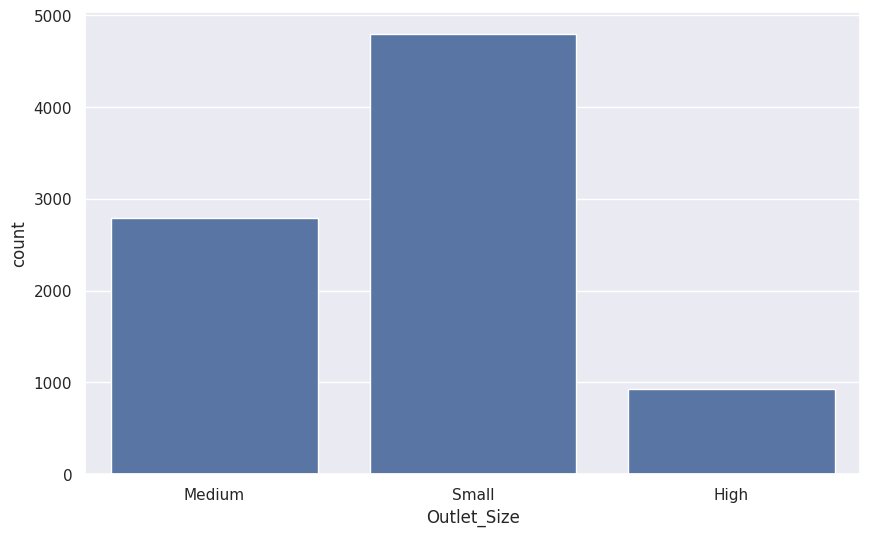

In [69]:
plt.figure(figsize=(10,6))
sns.countplot(x = 'Outlet_Size',data = training_data)
plt.show()

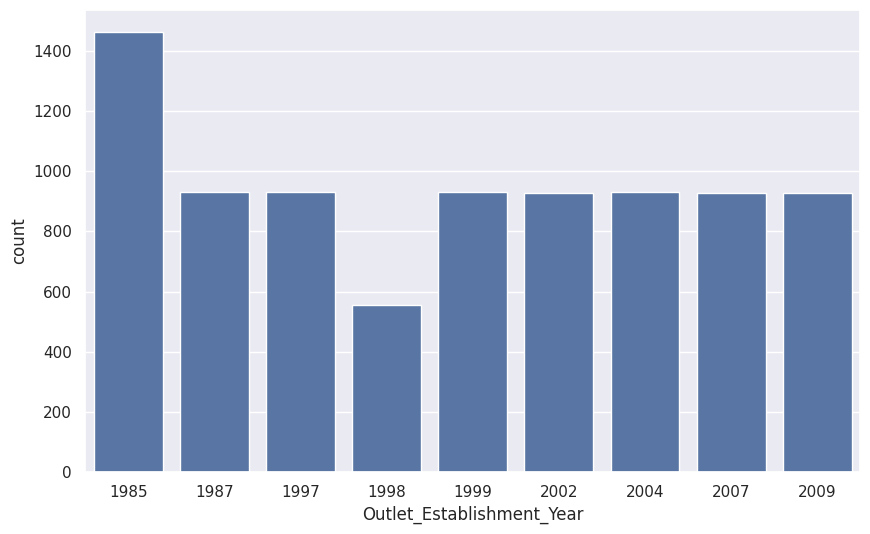

In [70]:
plt.figure(figsize=(10,6))
sns.countplot(x = 'Outlet_Establishment_Year',data = training_data)
plt.show()

In [71]:
cat_cols = training_data[['Item_Identifier','Item_Fat_Content','Item_Type','Outlet_Identifier','Outlet_Size','Outlet_Location_Type','Outlet_Type']]
for col in cat_cols:
  print(f"Value counts for '{col}' : " )
  display(training_data[col].value_counts())

Value counts for 'Item_Identifier' : 


,count
Item_Identifier,
FDW13,10
FDG33,10
FDX31,9
FDT07,9
NCY18,9
...,...
FDO33,1
FDK57,1
FDT35,1


Value counts for 'Item_Fat_Content' : 


,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


Value counts for 'Item_Type' : 


...

,count
Outlet_Size,
Small,4798
Medium,2793
High,932


Value counts for 'Outlet_Location_Type' : 


,count
Outlet_Location_Type,
Tier 3,3350
Tier 2,2785
Tier 1,2388


Value counts for 'Outlet_Type' : 


,count
Outlet_Type,
Supermarket Type1,5577
Grocery Store,1083
Supermarket Type3,935
Supermarket Type2,928


In [72]:
# Standardize 'Item_Fat_Content' column
training_data['Item_Fat_Content'] = training_data['Item_Fat_Content'].replace({'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'})

# Apply Label Encoding
le = LabelEncoder()
training_data['Item_Fat_Content'] = le.fit_transform(training_data['Item_Fat_Content'])

print("Value counts for 'Item_Fat_Content' in data after encoding:")
display(training_data['Item_Fat_Content'].value_counts())

Value counts for 'Item_Fat_Content' in data after encoding:


,count
Item_Fat_Content,
0,5517
1,3006


In [73]:
print("Value counts for 'Item_Type' : ")
display(training_data['Item_Type'].value_counts())

Value counts for 'Item_Type' : 


,count
Item_Type,
Fruits and Vegetables,1232
Snack Foods,1200
Household,910
Frozen Foods,856
Dairy,682
Canned,649
Baking Goods,648
Health and Hygiene,520
Soft Drinks,445


In [74]:
# One-hot encode 'Item_Type' column
training_data = pd.get_dummies(training_data, columns=['Item_Type'], prefix='Item_Type')
print("Data after one-hot encoding 'Item_Type':")
display(training_data.head())

Data after one-hot encoding 'Item_Type':


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,FDA15,9.30,0,0.016047,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,...,False,False,False,False,False,False,False,False,False,False
1,DRC01,5.92,1,0.019278,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,...,False,False,False,False,False,False,False,False,True,False
2,FDN15,17.50,0,0.016760,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,...,False,False,False,False,True,False,False,False,False,False
3,FDX07,19.20,1,0.000000,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,0,0.000000,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,...,False,False,False,True,False,False,False,False,False,False


In [75]:
print("Value counts for 'Outlet_Identifier':")
display(training_data['Outlet_Identifier'].value_counts())

Value counts for 'Outlet_Identifier':


,count
Outlet_Identifier,
OUT027,935
OUT013,932
OUT035,930
OUT049,930
OUT046,930
OUT045,929
OUT018,928
OUT017,926
OUT010,555


In [76]:
# One-hot encode 'Outlet_Identifier' column
training_data = pd.get_dummies(training_data, columns=['Outlet_Identifier'], prefix='Outlet_Identifier')

print("Data after one-hot encoding 'Outlet_Identifier':")
display(training_data.head())

Data after one-hot encoding 'Outlet_Identifier':


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,...,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049
0,FDA15,9.30,0,0.016047,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380,...,False,False,False,False,False,False,False,False,False,True
1,DRC01,5.92,1,0.019278,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228,...,False,False,False,True,False,False,False,False,False,False
2,FDN15,17.50,0,0.016760,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700,...,False,False,False,False,False,False,False,False,False,True
3,FDX07,19.20,1,0.000000,182.0950,1998,Small,Tier 3,Grocery Store,732.3800,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,0,0.000000,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052,...,False,True,False,False,False,False,False,False,False,False


In [77]:
training_data['Outlet_Size'] = le.fit_transform(training_data['Outlet_Size'])

print("Value counts for 'Outlet_Size' in Data after encoding:")
display(training_data['Outlet_Size'].value_counts())

Value counts for 'Outlet_Size' in Data after encoding:


,count
Outlet_Size,
2,4798
1,2793
0,932


In [78]:
training_data['Outlet_Location_Type'] = le.fit_transform(training_data['Outlet_Location_Type'])

print("Value counts for 'Outlet_Location_Type' in Data after encoding:")
display(training_data['Outlet_Location_Type'].value_counts())

Value counts for 'Outlet_Location_Type' in Data after encoding:


,count
Outlet_Location_Type,
2,3350
1,2785
0,2388


In [79]:
training_data['Outlet_Type'] = le.fit_transform(training_data['Outlet_Type'])

print("Value counts for 'Outlet_Type' in Data after encoding:")
display(training_data['Outlet_Type'].value_counts())

Value counts for 'Outlet_Type' in Data after encoding:


,count
Outlet_Type,
1,5577
0,1083
3,935
2,928


In [80]:
training_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,...,Outlet_Identifier_OUT010,Outlet_Identifier_OUT013,Outlet_Identifier_OUT017,Outlet_Identifier_OUT018,Outlet_Identifier_OUT019,Outlet_Identifier_OUT027,Outlet_Identifier_OUT035,Outlet_Identifier_OUT045,Outlet_Identifier_OUT046,Outlet_Identifier_OUT049
0,FDA15,9.30,0,0.016047,249.8092,1999,1,0,1,3735.1380,...,False,False,False,False,False,False,False,False,False,True
1,DRC01,5.92,1,0.019278,48.2692,2009,1,2,2,443.4228,...,False,False,False,True,False,False,False,False,False,False
2,FDN15,17.50,0,0.016760,141.6180,1999,1,0,1,2097.2700,...,False,False,False,False,False,False,False,False,False,True
3,FDX07,19.20,1,0.000000,182.0950,1998,2,2,0,732.3800,...,True,False,False,False,False,False,False,False,False,False
4,NCD19,8.93,0,0.000000,53.8614,1987,0,2,1,994.7052,...,False,True,False,False,False,False,False,False,False,False


In [85]:
X = training_data.drop(['Item_Identifier','Item_Outlet_Sales'], axis=1)
y = training_data['Item_Outlet_Sales']

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
# model = LinearRegression()

In [93]:
model_2 = XGBRegressor()

In [88]:
# model.fit(X_train, y_train)

LinearRegression()

In [94]:
model_2.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [89]:
# y_pred = model.predict(X_test)

In [95]:
y_pred_2 = model_2.predict(X_test)

In [90]:
# r2 = metrics.r2_score(y_test, y_pred)

In [96]:
r2_X = metrics.r2_score(y_test, y_pred_2)

In [91]:
# r2

0.5792664114419452

In [97]:
r2_X

0.5184722239382848

In [101]:
input_data = (10.0, 0.0, 0.05, 150.0, 2000.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0) # Example with 34 features

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = model.predict(input_data_reshaped)

print(f"\nPredicted Item Outlet Sales: {prediction[0]:.2f}")


Predicted Item Outlet Sales: 2214.16
